In [3]:
# ESP32 Tiny Speech Command Classifier

import os, pathlib
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras import layers
from sklearn.model_selection import train_test_split

In [8]:
# Paths
DATASET_PATH = "data"
commands = np.array(tf.io.gfile.listdir(str(DATASET_PATH)))
commands = commands[commands != "_background_noise_"]
print("Commands:", commands)

# Load and preprocess WAVs
def decode_audio(audio_binary):
    audio, _ = tf.audio.decode_wav(audio_binary)
    return tf.squeeze(audio, axis=-1)

def get_label(file_path):
    parts = tf.strings.split(file_path, os.path.sep)
    return parts[-2]

def add_noise(waveform, noise_factor=0.1):
    noise = tf.random.normal(shape=tf.shape(waveform), mean=0.0, stddev=noise_factor)
    return waveform + noise

def time_shift(waveform, shift_factor=0.1):
    shift = int(len(waveform) * shift_factor)
    if tf.random.uniform([]) > 0.5:
        return tf.roll(waveform, shift, 0)
    else:
        return tf.roll(waveform, -shift, 0)

def preprocess(file_path, augment=False):
    label = get_label(file_path)
    audio_binary = tf.io.read_file(file_path)
    waveform = decode_audio(audio_binary)
    
    # Pad/trim to 1 sec
    waveform = waveform[:16000]
    zero_padding = tf.zeros([16000] - tf.shape(waveform), dtype=tf.float32)
    waveform = tf.concat([waveform, zero_padding], 0)
    
    # Apply augmentation
    if augment:
        if tf.random.uniform([]) > 0.5:
            waveform = add_noise(waveform)
        if tf.random.uniform([]) > 0.5:
            waveform = time_shift(waveform)
    
    return waveform, label

# Load file paths
filenames = tf.io.gfile.glob(str(DATASET_PATH) + '/*/*.wav')
waveforms = []
labels = []

# Use full dataset and create augmented versions
for f in filenames:
    # Original sample
    w, l = preprocess(f, augment=False)
    waveforms.append(w)
    labels.append(l.numpy().decode())
    
    # Augmented sample
    w_aug, l_aug = preprocess(f, augment=True)
    waveforms.append(w_aug)
    labels.append(l_aug.numpy().decode())

label_names = sorted(set(labels))
label_to_index = {name: i for i, name in enumerate(label_names)}
print("Labels:", label_to_index)

# Save label mapping so inference can load the exact ordering
import json
with open('labels.json', 'w') as f:
    json.dump({'label_names': label_names, 'label_to_index': label_to_index}, f)

waveforms = np.array([w.numpy() for w in waveforms])
labels = np.array([label_to_index[l] for l in labels])

# Convert to spectrograms
def get_spectrogram(waveform):
    spectrogram = tf.signal.stft(waveform, frame_length=255, frame_step=128)
    spectrogram = tf.abs(spectrogram)
    return spectrogram

spectrograms = np.array([get_spectrogram(w) for w in waveforms])
spectrograms = spectrograms[..., np.newaxis]

# Split with stratification
X_train, X_test, y_train, y_test = train_test_split(spectrograms, labels, test_size=0.2, random_state=42, stratify=labels)

# Build larger CNN
model = tf.keras.Sequential([
    layers.Input(shape=X_train.shape[1:]),
    layers.Conv2D(32, 3, activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D(),
    layers.Conv2D(64, 3, activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D(),
    layers.Conv2D(128, 3, activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D(),
    layers.Dropout(0.3),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.3),
    layers.Dense(len(label_names), activation='softmax')
])

model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

print("\nModel Summary:")
model.summary()

# Train with more epochs
history = model.fit(X_train, y_train, 
                   epochs=30, 
                   batch_size=32,
                   validation_data=(X_test, y_test),
                   callbacks=[
                       tf.keras.callbacks.EarlyStopping(
                           monitor='val_loss',
                           patience=5,
                           restore_best_weights=True
                       )
                   ])

# Evaluate
loss, acc = model.evaluate(X_test, y_test)
print(f"\nFinal Test Accuracy: {acc*100:.2f}%")

Commands: ['no' 'yes']
Labels: {'_background_noise_': 0, 'no': 1, 'yes': 2}
Labels: {'_background_noise_': 0, 'no': 1, 'yes': 2}

Model Summary:
Model: "sequential_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d_3 (Conv2D)           (None, 124, 129, 32)      320       
                                                                 
 batch_normalization_4 (Batc  (None, 124, 129, 32)     128       
 hNormalization)                                                 
                                                                 
 max_pooling2d_3 (MaxPooling  (None, 62, 64, 32)       0         
 2D)                                                             
                                                                 
 conv2d_4 (Conv2D)           (None, 62, 64, 64)        18496     

Model Summary:
Model: "sequential_1"
_________________________________________________________________
 La

INFO:tensorflow:Assets written to: C:\Users\kukil\AppData\Local\Temp\tmpxyjrr47y\assets


INFO:tensorflow:Assets written to: C:\Users\kukil\AppData\Local\Temp\tmpxyjrr47y\assets


Saved speech_esp32.tflite
✅ model.h ready for Arduino
✅ model.h ready for Arduino


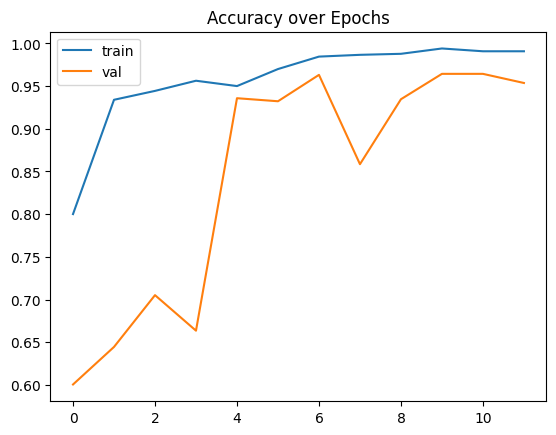

In [9]:
# Quantize to TFLite
def representative_dataset():
    for i in range(100):
        yield [X_train[i:i+1].astype(np.float32)]

converter = tf.lite.TFLiteConverter.from_keras_model(model)
converter.optimizations = [tf.lite.Optimize.DEFAULT]
converter.representative_dataset = representative_dataset
converter.target_spec.supported_types = [tf.float16]
tflite_model = converter.convert()

with open("speech_esp32.tflite", "wb") as f:
    f.write(tflite_model)
print("Saved speech_esp32.tflite")

# Convert to C Array
def convert_to_c_array(tflite_model):
    hex_data = ', '.join(['0x{:02x}'.format(x) for x in tflite_model])
    c_array = f"const unsigned char model_tflite[] = {{{hex_data}}};\nconst int model_tflite_len = {len(tflite_model)};"
    with open("model.h", "w") as f:
        f.write(c_array)
    print("✅ model.h ready for Arduino")

convert_to_c_array(tflite_model)

# Plot Accuracy
plt.plot(history.history['accuracy'], label='train')
plt.plot(history.history['val_accuracy'], label='val')
plt.legend(), plt.title("Accuracy over Epochs")
plt.show()

In [10]:
# Test on pre-recorded audio files
import numpy as np
import tensorflow as tf
import os
import glob
import json

# Load labels from saved mapping
try:
    with open('labels.json', 'r') as f:
        labels_info = json.load(f)
    if isinstance(labels_info, dict):
        labels = labels_info.get('label_names', [])
    else:
        labels = labels_info
    print('Loaded labels:', labels)
except Exception as e:
    # Fallback labels (old behavior)
    labels = ['_background_noise_', 'yes']
    print('Could not load labels.json, using fallback labels:', labels)

# Load model
interpreter = tf.lite.Interpreter(model_path="speech_esp32.tflite")
interpreter.allocate_tensors()
input_details = interpreter.get_input_details()
output_details = interpreter.get_output_details()

# Function to process audio file
def process_audio_file(file_path):
    # Load and decode audio
    audio_binary = tf.io.read_file(file_path)
    audio, _ = tf.audio.decode_wav(audio_binary)
    audio = tf.squeeze(audio)
    
    # Pad/trim to 1 sec
    if len(audio) < 16000:
        audio = np.pad(audio, (0, 16000 - len(audio)), mode='constant')
    else:
        audio = audio[:16000]
    
    # Compute spectrogram
    stft = tf.signal.stft(audio, frame_length=255, frame_step=128)
    spectrogram = tf.abs(stft).numpy()
    
    # Add batch and channel dims
    spectrogram = np.expand_dims(spectrogram, axis=-1)
    spectrogram = np.expand_dims(spectrogram, axis=0)
    
    return spectrogram

# Test directories
test_dirs = [
    "../../Dataset/test-sound/yes",
    "../../Dataset/test-sound/no"
]

# Process all test directories
for test_dir in test_dirs:
    # Get all wav files from the test directory
    test_files = glob.glob(os.path.join(test_dir, "*.wav"))
    
    print(f"\nTesting files from: {os.path.basename(test_dir)}")
    print(f"Found {len(test_files)} test files")
    print("-" * 50)
    
    # Process each file
    correct = 0
    total = len(test_files)
    
    for file_path in test_files:
        # Get filename for display
        filename = os.path.basename(file_path)
        true_label = os.path.basename(os.path.dirname(file_path))
        
        # Process audio
        spectrogram = process_audio_file(file_path)
        
        # Run inference
        interpreter.set_tensor(input_details[0]['index'], spectrogram.astype(np.float32))
        interpreter.invoke()
        
        # Get results
        output_data = interpreter.get_tensor(output_details[0]['index'])
        pred_class = int(np.argmax(output_data))
        confidence = float(np.max(output_data))
        
        # Check if prediction is correct
        predicted_label = labels[pred_class] if pred_class < len(labels) else f'index_{pred_class}'
        if predicted_label == true_label:
            correct += 1
            result = "✅"
        else:
            result = "❌"
            
        # Print results
        print(f"File: {filename}")
        print(f"True label: {true_label}")
        print(f"Predicted: {predicted_label} (confidence: {confidence:.2f}) {result}")
        print("-" * 50)
    
    # Print accuracy for this directory
    accuracy = (correct / total) * 100 if total > 0 else 0
    print(f"\nAccuracy for {os.path.basename(test_dir)}: {accuracy:.1f}% ({correct}/{total})")
    print("=" * 50)

Loaded labels: ['_background_noise_', 'no', 'yes']

Testing files from: yes
Found 18 test files
--------------------------------------------------
File: 1b42b551_nohash_2.wav
True label: yes
Predicted: yes (confidence: 1.00) ✅
--------------------------------------------------
File: 1b42b551_nohash_3.wav
True label: yes
Predicted: yes (confidence: 1.00) ✅
--------------------------------------------------
File: 1b755c65_nohash_0.wav
True label: yes
Predicted: yes (confidence: 1.00) ✅
--------------------------------------------------
File: 1b88bf70_nohash_0.wav
True label: yes
Predicted: yes (confidence: 1.00) ✅
--------------------------------------------------
File: 1b88bf70_nohash_1.wav
True label: yes
Predicted: yes (confidence: 1.00) ✅
--------------------------------------------------
File: 1c1060b1_nohash_0.wav
True label: yes
Predicted: yes (confidence: 0.96) ✅
--------------------------------------------------
File: 1c1060b1_nohash_1.wav
True label: yes
Predicted: yes (confide

In [7]:
# Check the actual labels from training
import json

# Load the TFLite model
interpreter = tf.lite.Interpreter(model_path="speech_esp32.tflite")
interpreter.allocate_tensors()

# Get the label mapping from the original training
DATASET_PATH = "data"
filenames = tf.io.gfile.glob(str(DATASET_PATH) + '/*/*.wav')
train_labels = []
for f in filenames:
    parts = tf.strings.split(f, os.path.sep)
    train_labels.append(parts[-2].numpy().decode())

actual_label_names = sorted(set(train_labels))
actual_label_to_index = {name: i for i, name in enumerate(actual_label_names)}

print("Labels used in training:", actual_label_names)
print("Label to index mapping:", json.dumps(actual_label_to_index, indent=2))

# Current hardcoded labels we're using
print("\nLabels we're using in inference:", labels)

Labels used in training: ['_background_noise_', 'yes']
Label to index mapping: {
  "_background_noise_": 0,
  "yes": 1
}

Labels we're using in inference: ['no', 'yes', '_background_noise_']
